# Does Proxy-Based Data Selection Survive Contact With Reality?
### *Robustness and Net-Cost Accounting for Efficient Instruction Tuning*

**Research & EDA Findings Notebook**

This notebook presents the empirical evidence, exploratory data analysis (EDA), and core findings of our research project. It brings together dataset properties, selection behavior, measured selection overheads, hyperparameter sensitivity, and Pareto efficiency.

---

In [1]:
# Environment & Path Setup
import os
import sys
import json
import glob
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image, HTML, Markdown

# Set working directory to project root
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from data import load_split, load_train_examples
from registry import load_runs
from stats import pareto_frontier, ranking_stability, holm_bonferroni, paired_bootstrap

print(f"Project Root: {ROOT}")
runs = load_runs(ROOT / "results/runs.jsonl")
ok = [r for r in runs if r.get("status") == "ok"]
print(f"Loaded {len(runs)} total run records ({len(ok)} successful runs).")

C:\Users\dell\AppData\Roaming\Python\Python313\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.3.0) or chardet (6.0.0.post1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


Project Root: D:\Ai\efficient-genai-research
note: collapsed 58 duplicate run_id record(s), keeping the latest
Loaded 30 total run records (29 successful runs).


--- 
## 1. Frozen Dataset Split & EDA Overview

We construct a strictly frozen 14,000 / 1,000 train/held-out split of the `databricks-dolly-15k` dataset. A hash of the prompt template is embedded into `results/split.json` to guarantee template stability across experiments.

Pool Dataset     : databricks/databricks-dolly-15k (15011 examples)
Train / Held-out : 14000 / 1000
Template Hash    : cb11391ee245


,Field,Mean,Median,Min,Max
0,Instruction Word Count,12.3,10.0,1,841
1,Response Word Count,60.3,31.0,1,4274



Figure: Dataset Overview (Length Distributions & Category Composition)


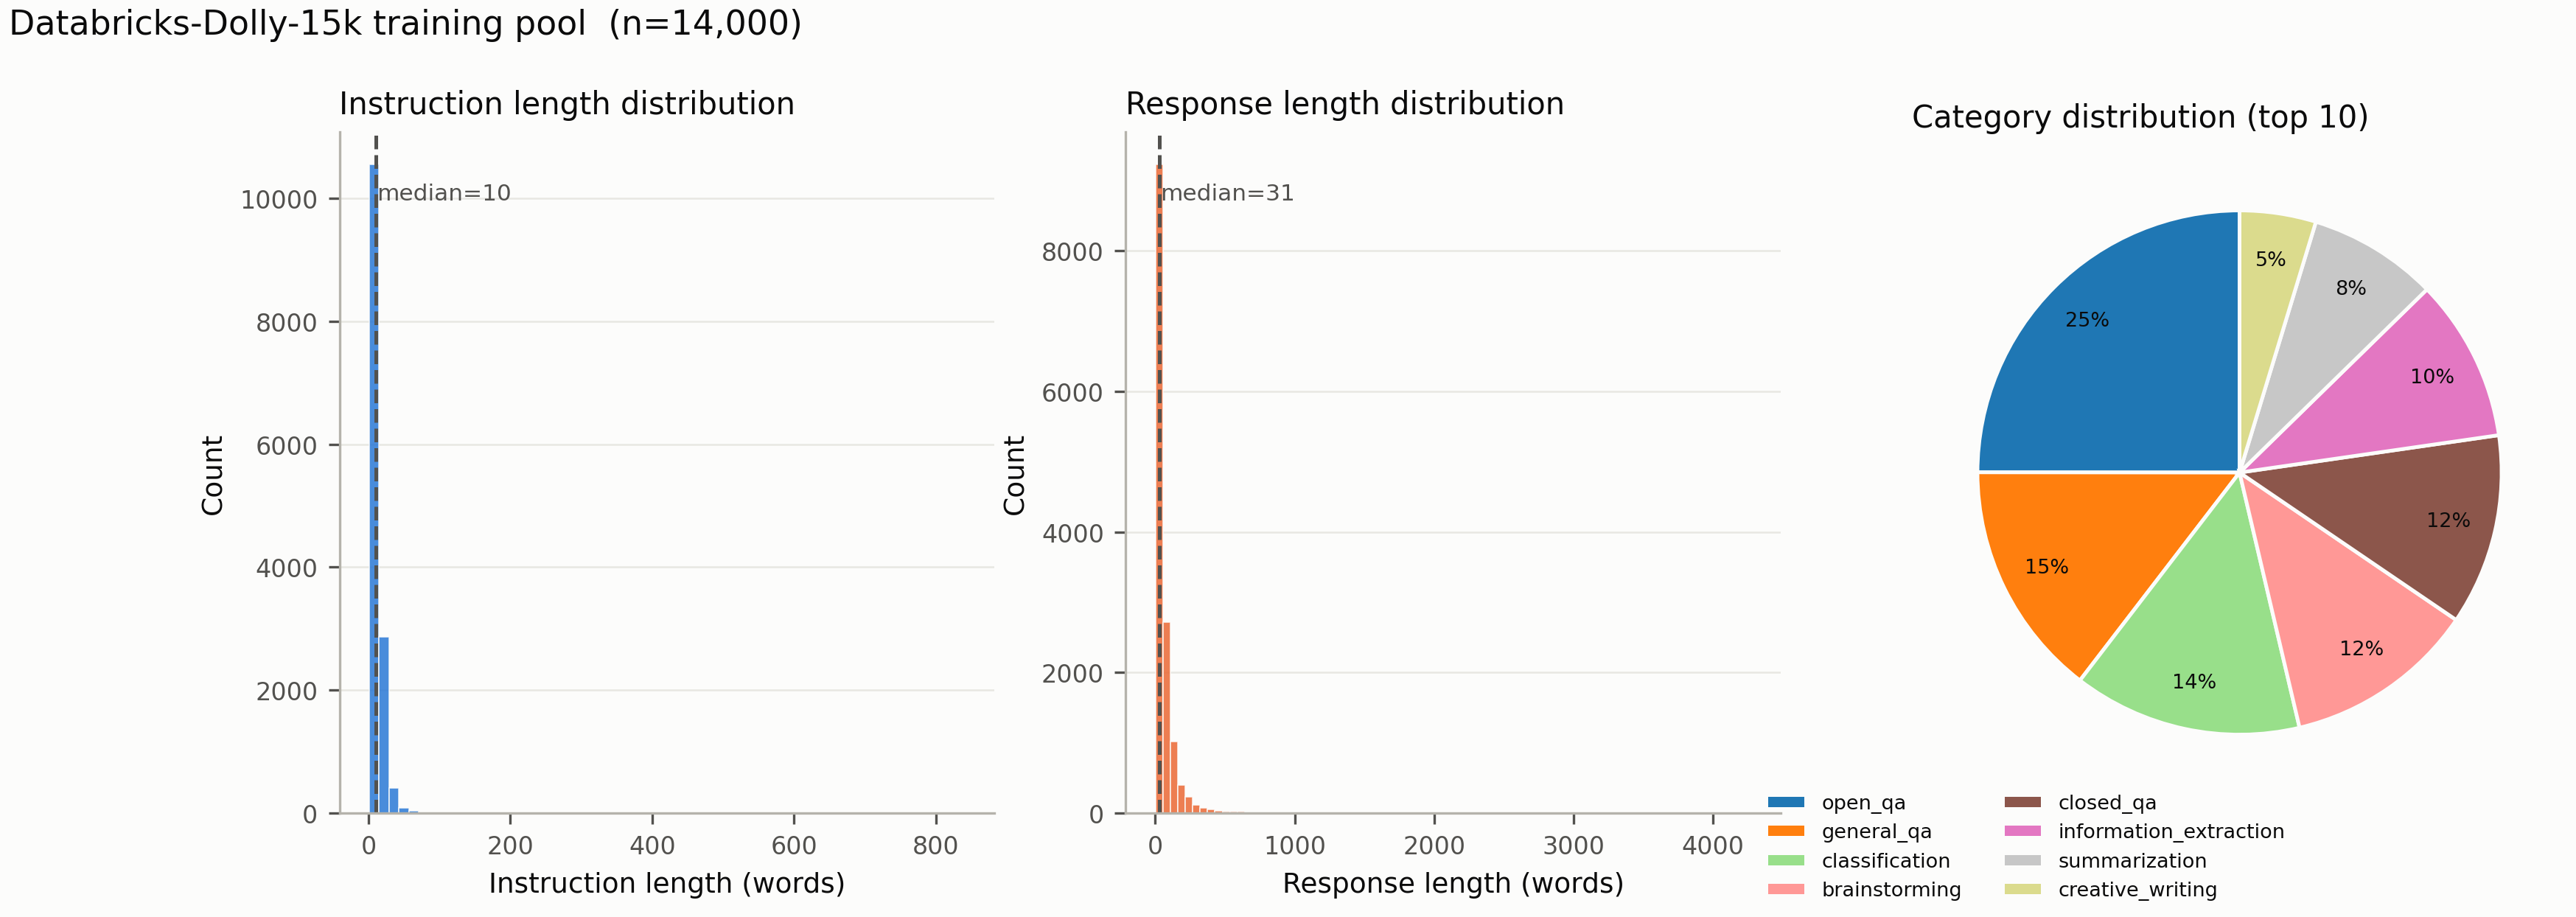

In [2]:
split = json.loads((ROOT / "results/split.json").read_text())
examples = load_train_examples()

print(f"Pool Dataset     : {split['pool']} ({split['pool_size']} examples)")
print(f"Train / Held-out : {len(split['train_idx'])} / {len(split['held_out_idx'])}")
print(f"Template Hash    : {split['template_hash']}")

instr_lens = [len(e["instruction"].split()) for e in examples]
resp_lens  = [len(e["response"].split()) for e in examples]

df_stats = pd.DataFrame({
    "Field": ["Instruction Word Count", "Response Word Count"],
    "Mean": [np.mean(instr_lens), np.mean(resp_lens)],
    "Median": [np.median(instr_lens), np.median(resp_lens)],
    "Min": [np.min(instr_lens), np.min(resp_lens)],
    "Max": [np.max(instr_lens), np.max(resp_lens)]
})
display(df_stats.style.format({"Mean": "{:.1f}", "Median": "{:.1f}"}).set_caption("Dataset Length Statistics"))

fig_path = ROOT / "results/figures/eda1_dataset_overview.png"
if fig_path.exists():
    print("\nFigure: Dataset Overview (Length Distributions & Category Composition)")
    display(Image(filename=str(fig_path)))

--- 
## 2. Selection Method Scorer Distributions & Selection Overlap

We compare 6 distinct selection strategies:
1. **Random** baseline
2. **Perplexity** (SmolLM-135M forward pass loss)
3. **Embedding Diversity** (SentenceTransformer MiniLM + facility location)
4. **Hybrid** (Perplexity + Diversity)
5. **IFD** (Instruction Following Difficulty: conditional vs unconditional loss ratio)
6. **Learning Percentage** (Proxy training loss reduction over 1 epoch)

Below we examine how these selection methods distribute scores, whether they suffer from length bias, and how much their selected sub-sets overlap (Jaccard similarity).


Figure 2a: Selection Pool Position Histograms


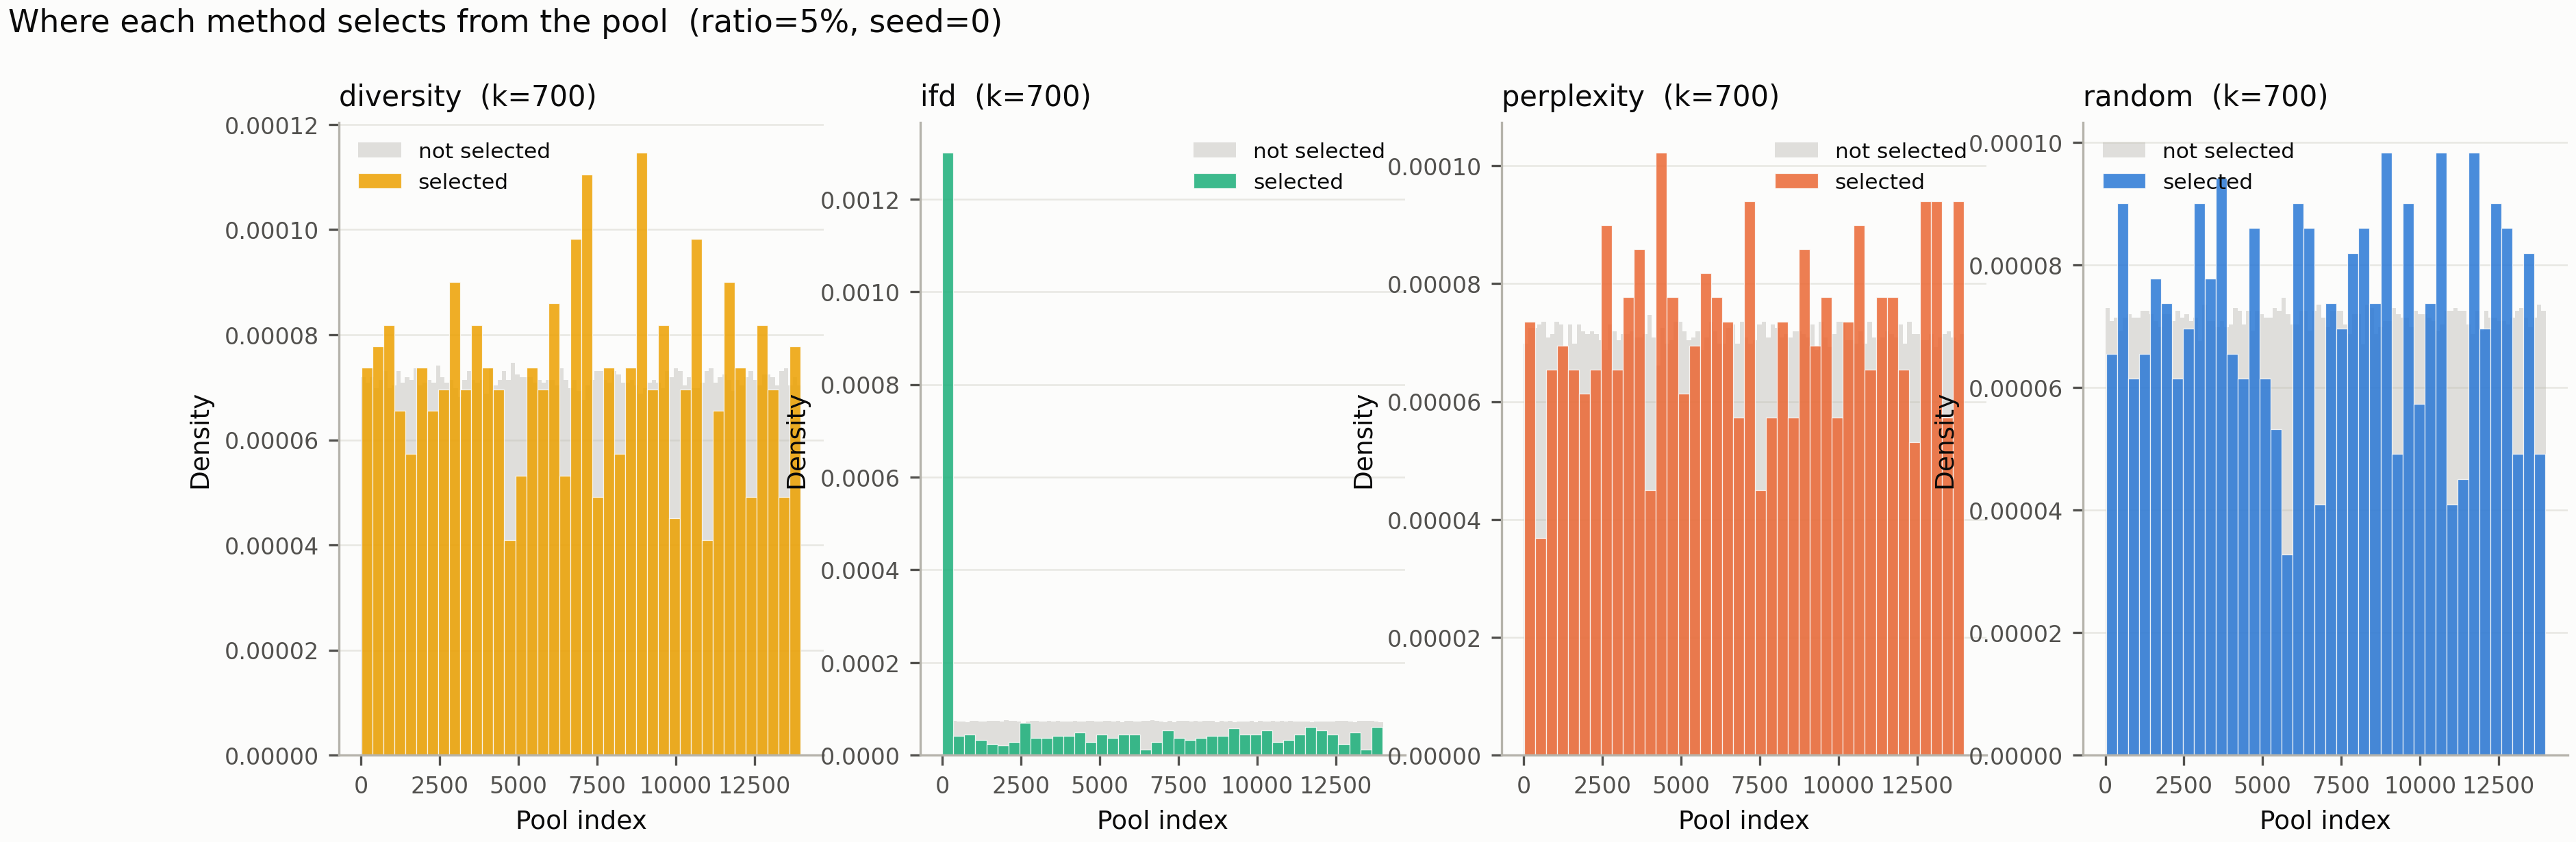


Figure 2b: Jaccard Similarity Heatmap Between Selection Methods


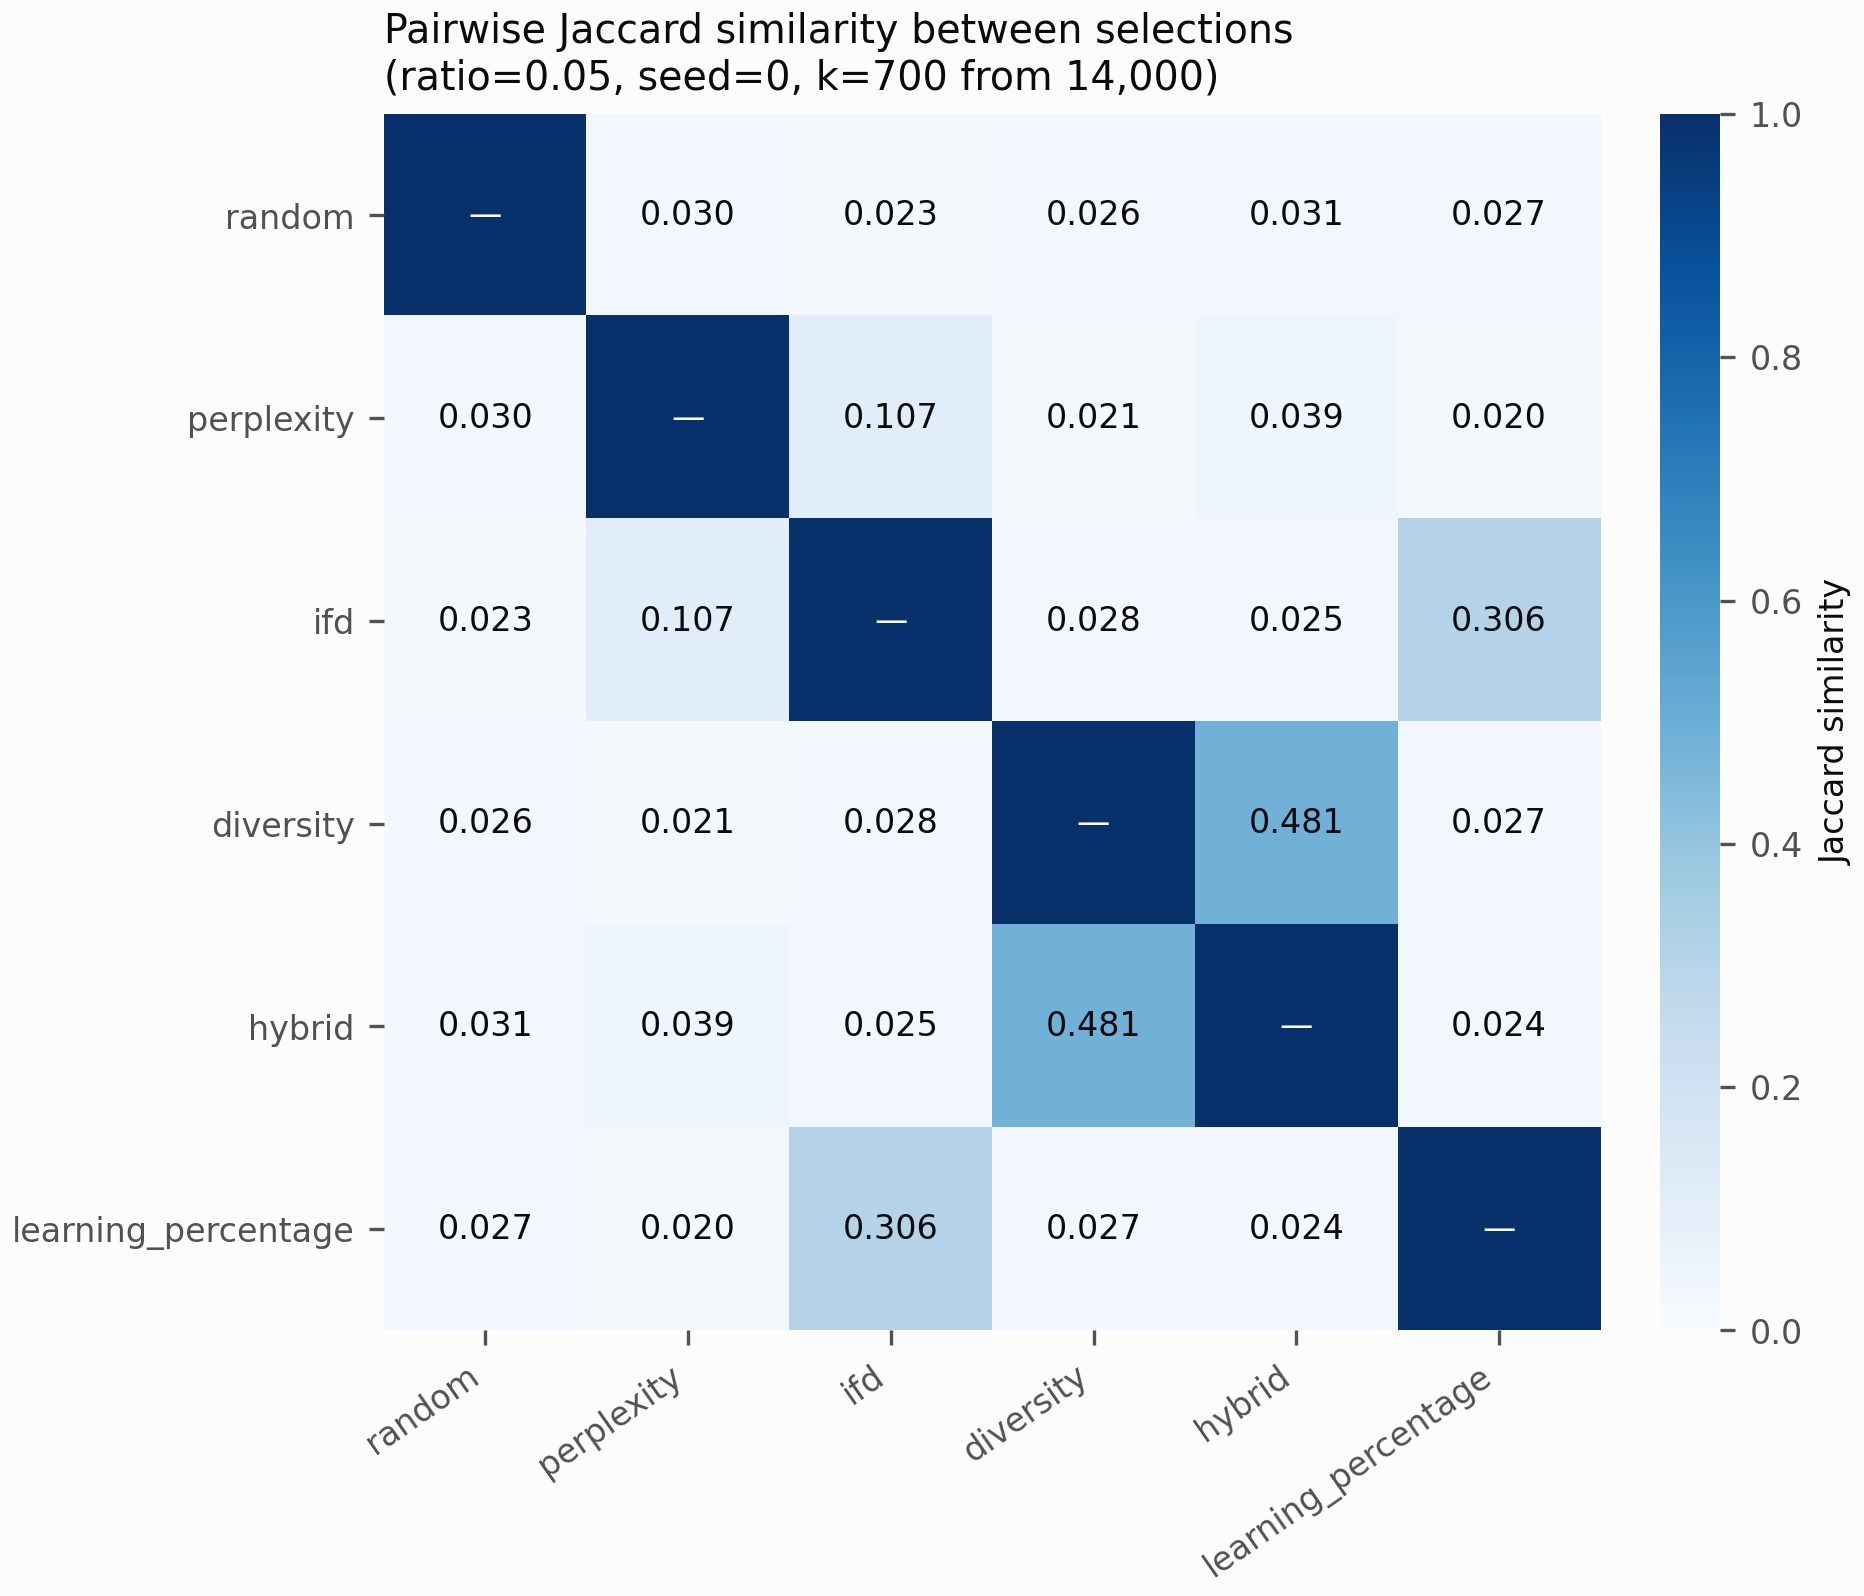


Figure 2c: Response Length Bias Across Methods


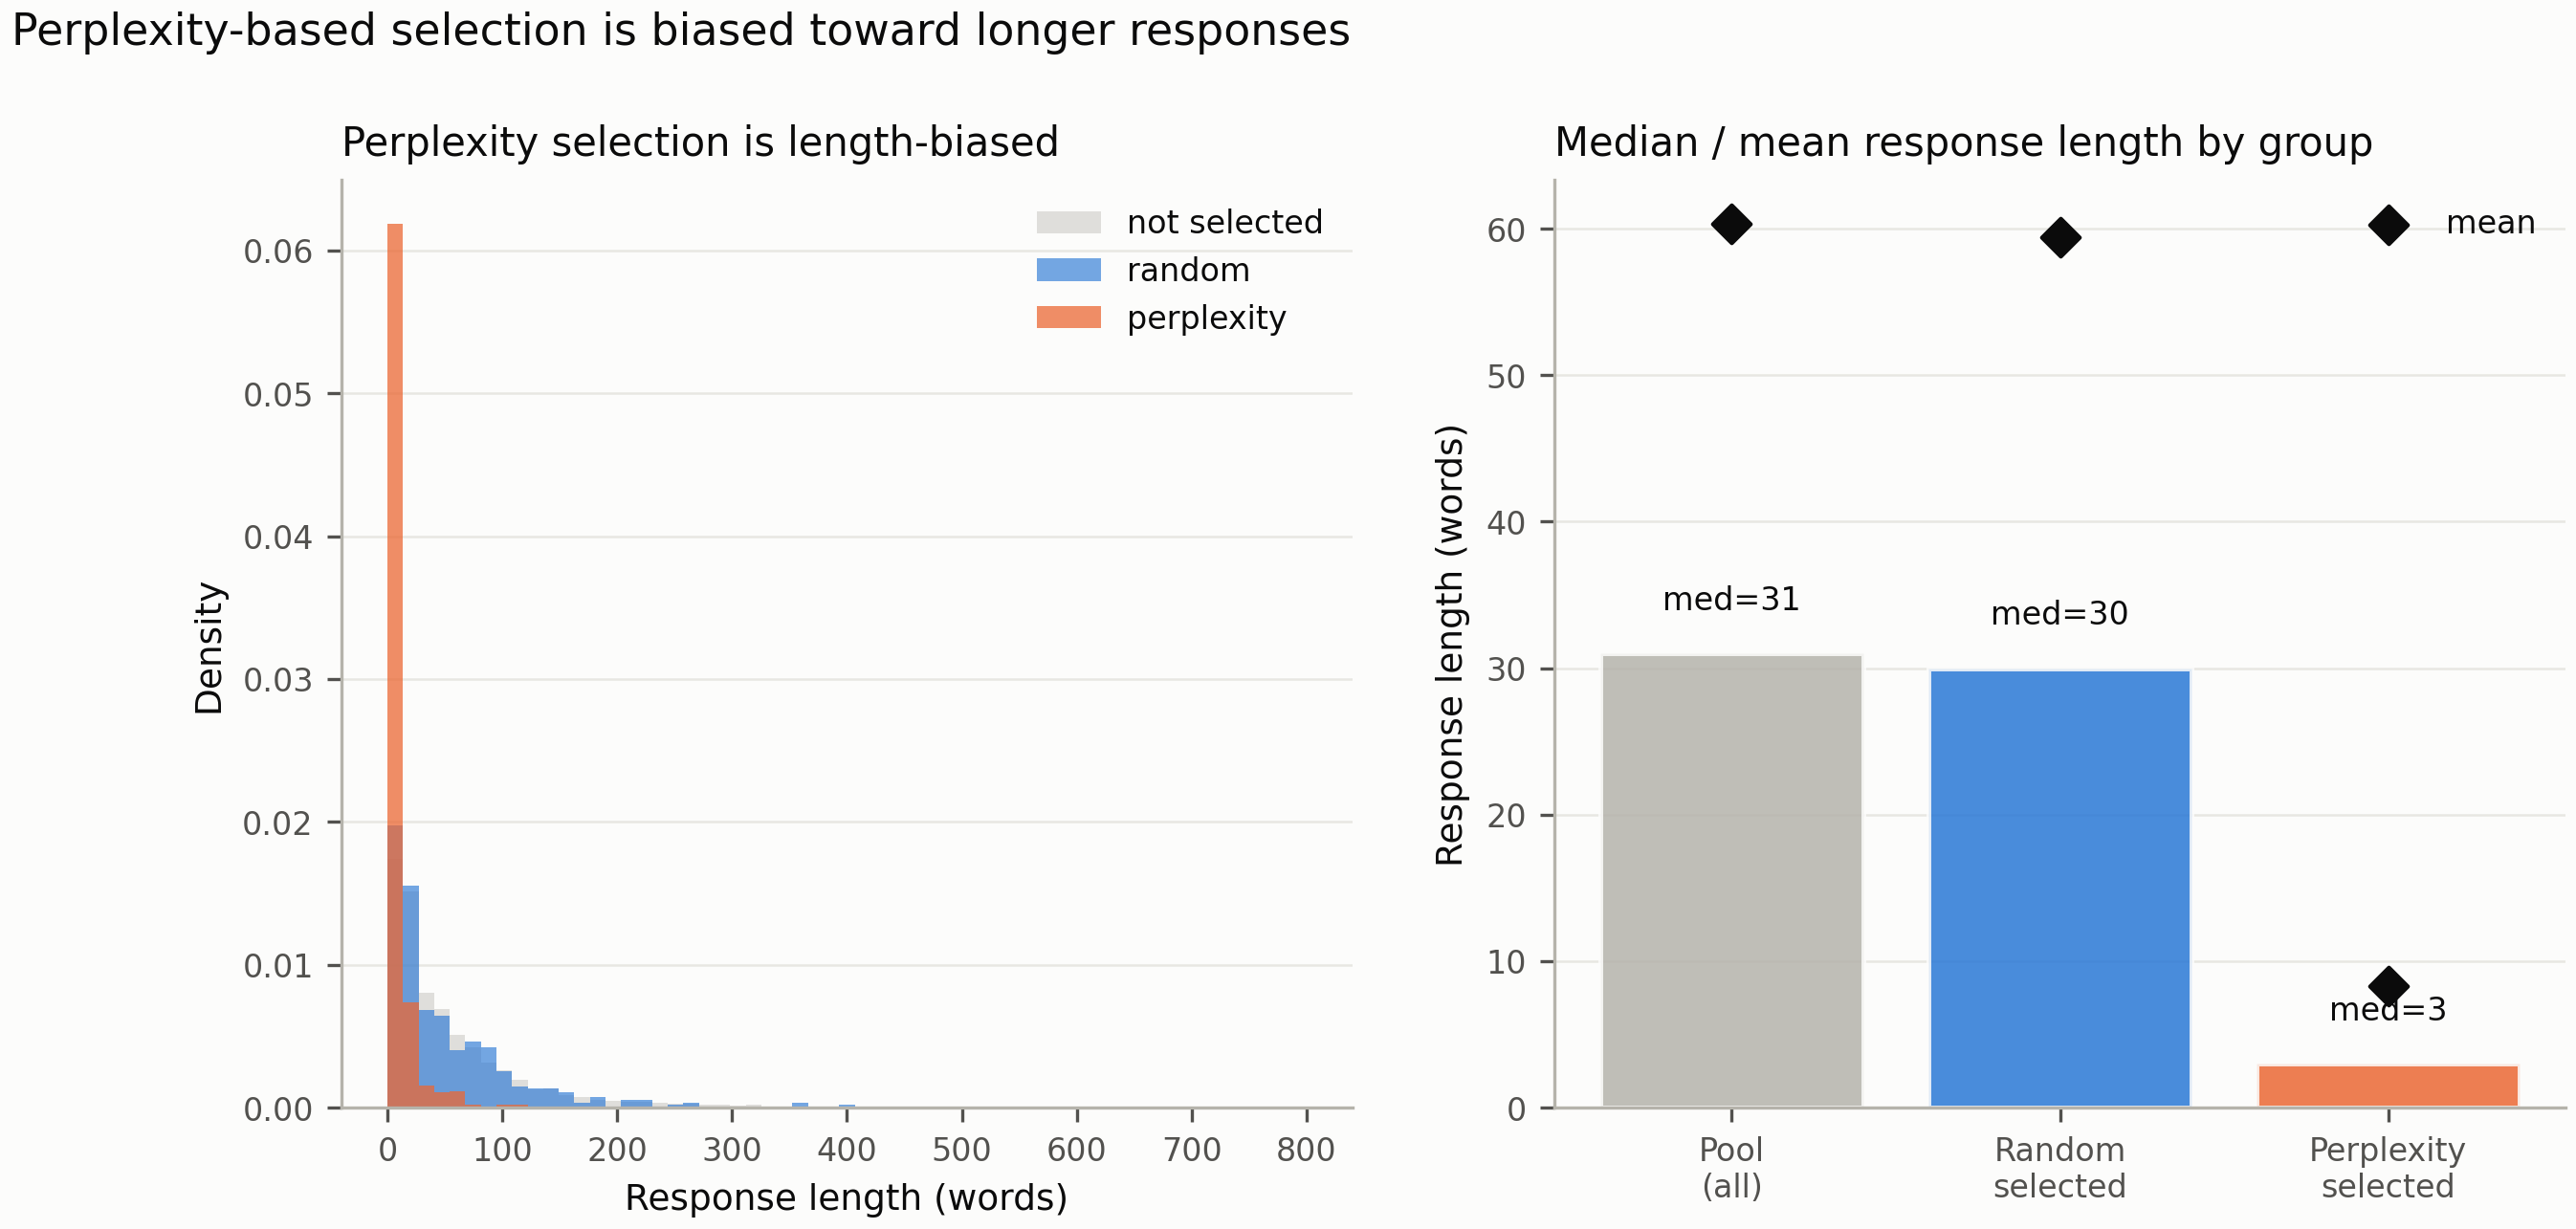

In [3]:
fig_files = [
    ("eda2_score_distributions.png", "Figure 2a: Selection Pool Position Histograms"),
    ("eda3_selection_overlap.png", "Figure 2b: Jaccard Similarity Heatmap Between Selection Methods"),
    ("eda4_length_bias.png", "Figure 2c: Response Length Bias Across Methods")
]

for fname, caption in fig_files:
    p = ROOT / "results/figures" / fname
    if p.exists():
        print(f"\n{caption}")
        display(Image(filename=str(p)))

--- 
## 3. Honest Selection Cost Accounting (RQ2)

**Key Insight:** Prior literature assumes data selection is free. In reality, every selection method must compute scores over the full dataset candidate pool ($N = 14,000$) before target fine-tuning can start.

We measure selection cost in analytical **FLOPs** as well as **wall-clock time**.

,Method,Cost Class,Wall-Clock (s),Selection FLOPs,Scorer Model
5,random,free,0.0,0.000e+00,-
0,diversity,training-free,58.0,9.379e+13,all-MiniLM-L6-v2
4,perplexity,training-free,493.7,7.119e+14,SmolLM-135M
1,hybrid,training-free,1900.8,8.056e+14,SmolLM-135M
2,ifd,training-free,959.3,1.005e+15,SmolLM-135M
3,learning_percentage,training-based,1624.7,3.570e+15,SmolLM-135M



Figure 3: Stacked Compute Breakdown (Selection FLOPs vs. Training FLOPs)


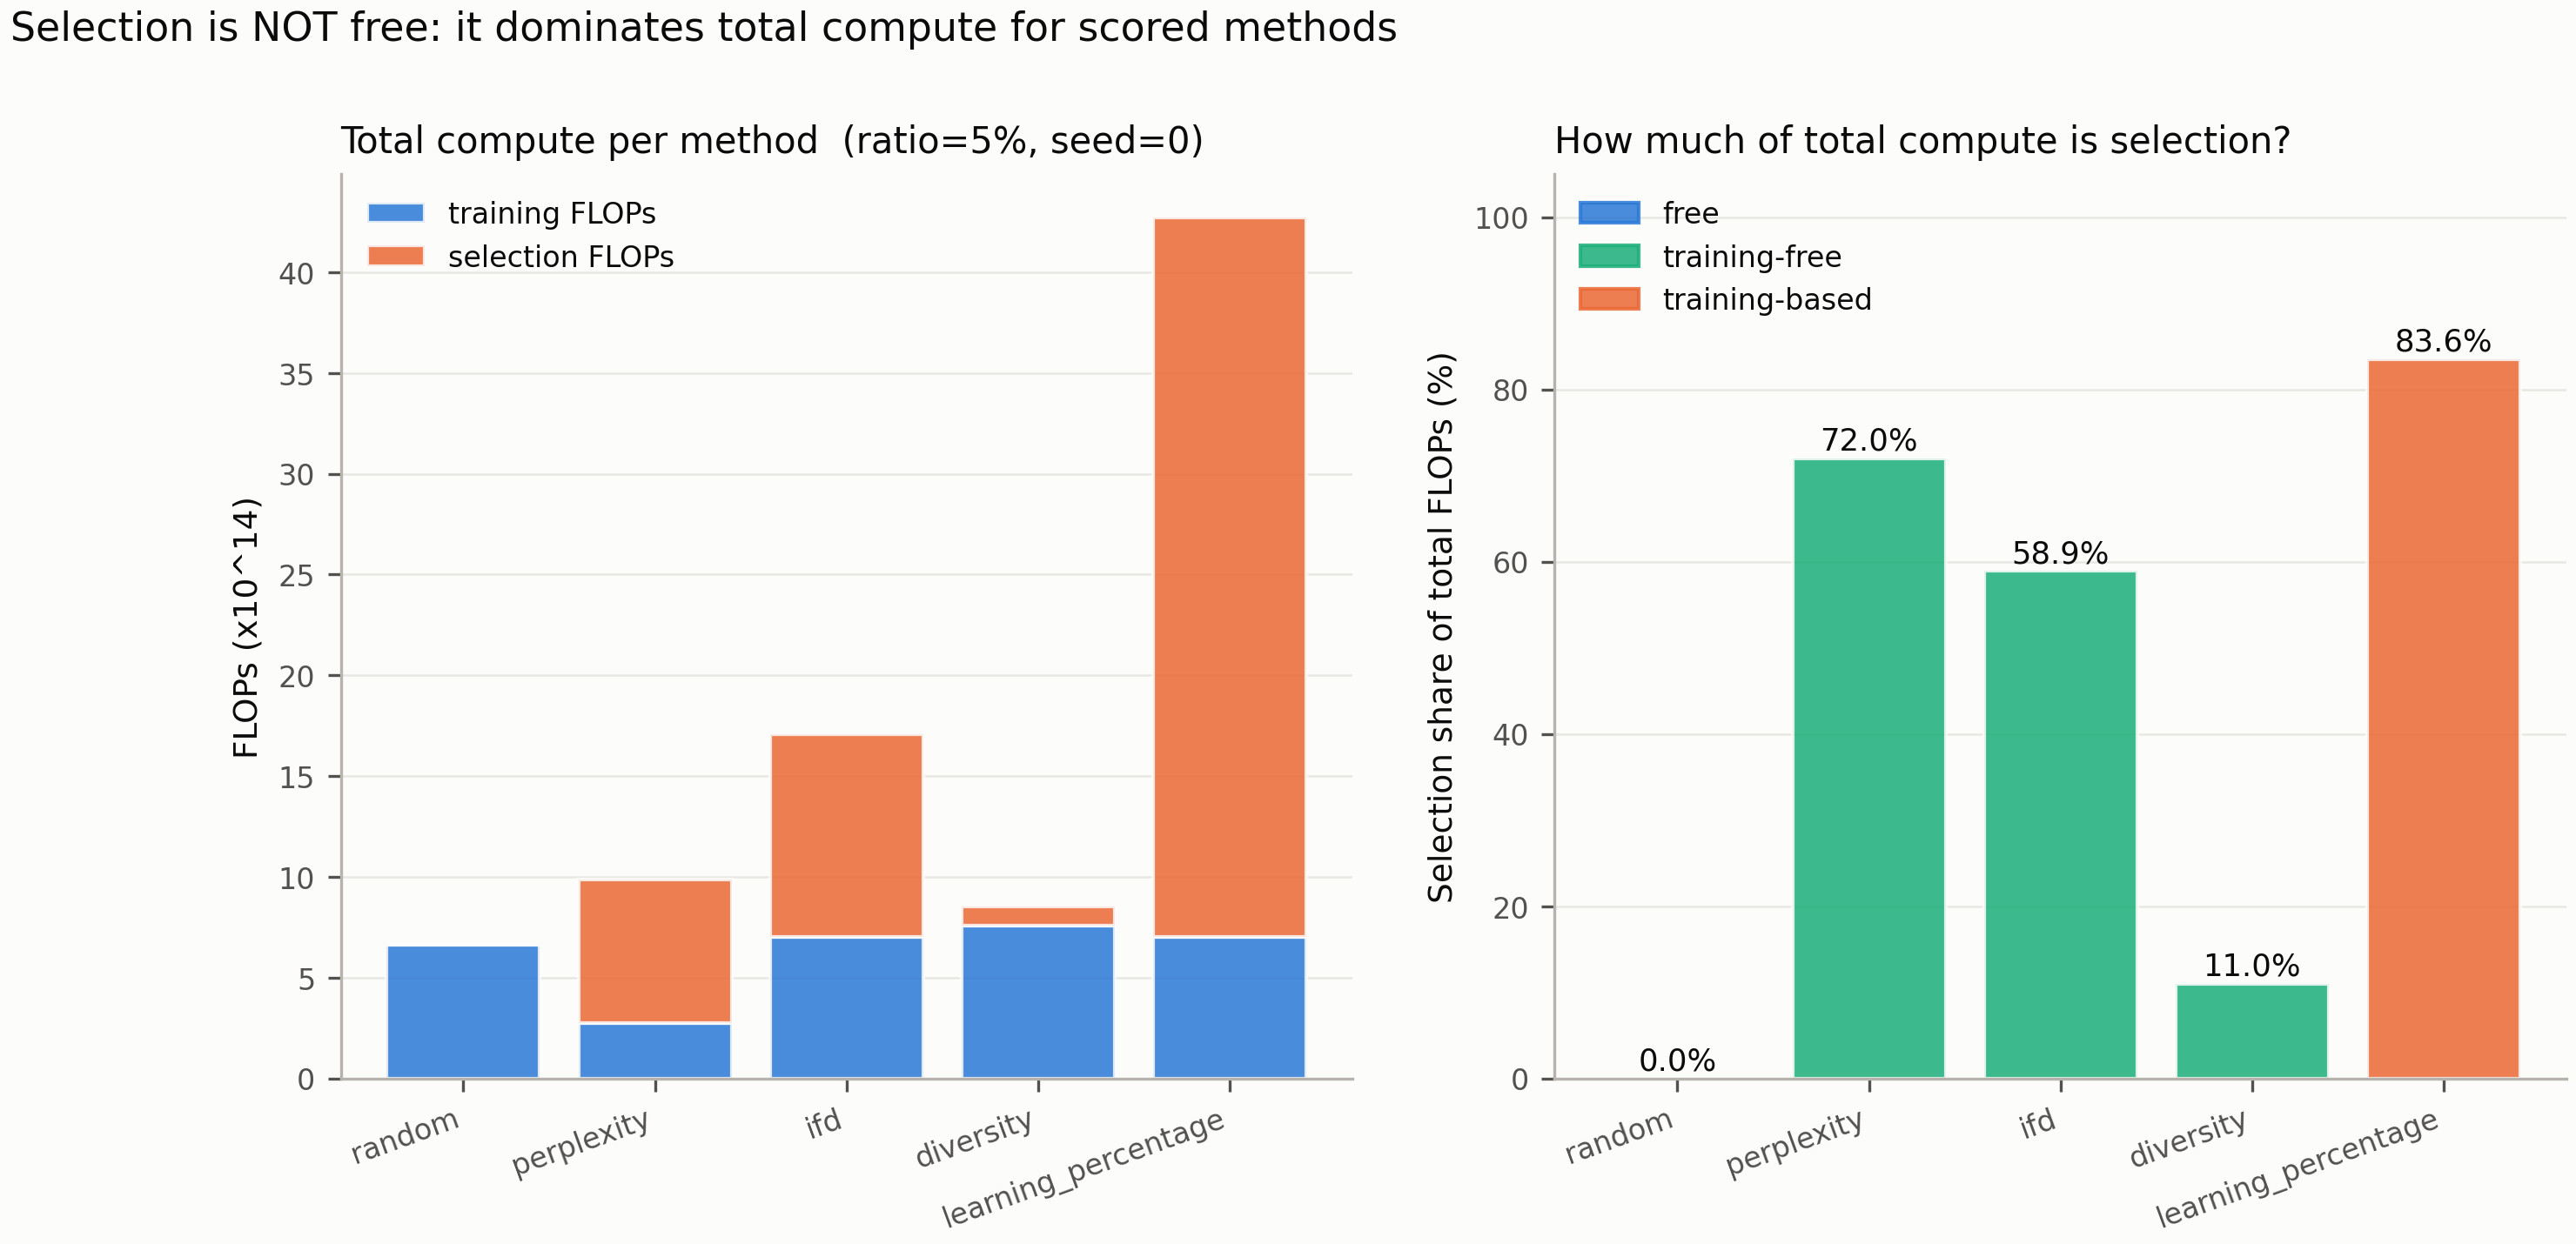

In [4]:
sel_files = sorted(glob.glob(str(ROOT / "results/selections/*__r0.05__s0.json")))
cost_rows = []
for f in sel_files:
    d = json.load(open(f))
    cfg = d["selector_config"]
    scorer = cfg.get("scorer") or cfg.get("embedder") or cfg.get("proxy") or "-"
    cost_rows.append({
        "Method": d["method"],
        "Cost Class": d["cost_class"],
        "Wall-Clock (s)": d["cost"]["wall_clock_s"],
        "Selection FLOPs": d["cost"]["flops"],
        "Scorer Model": scorer.split("/")[-1]
    })

df_cost = pd.DataFrame(cost_rows).sort_values(by="Selection FLOPs")
display(df_cost.style.format({"Wall-Clock (s)": "{:.1f}", "Selection FLOPs": "{:.3e}"}).set_caption("Measured Selection Overhead per Method (14k candidates)"))

p_cost = ROOT / "results/figures/eda5_cost_breakdown.png"
if p_cost.exists():
    print("\nFigure 3: Stacked Compute Breakdown (Selection FLOPs vs. Training FLOPs)")
    display(Image(filename=str(p_cost)))

--- 
## 4. Main Grid Results & Net-Cost Pareto Frontier (RQ2 Evidence)

Below we examine the experimental results across selection ratios (5% and 10%) on `Qwen2.5-0.5B`.

When evaluating efficiency claims:
1. **Training-Only FLOPs**: standard literature view (ignoring selection cost).
2. **Total FLOPs (Selection + Training)**: true net-cost view.

**Finding:** Methods like `perplexity` leave the Pareto frontier completely once their selection FLOPs are priced in!

,Method,Ratio,Held-out Loss (Mean),Std Dev,Selection FLOP Share (%),Total FLOPs
0,ifd,5%,1.7789,0.0042,58.9%,1.71e+15
1,random,5%,1.7972,0.0133,0.0%,6.63e+14
2,diversity,5%,1.7994,0.0001,11.0%,8.54e+14
3,learning_percentage,5%,1.8096,0.0056,83.6%,4.27e+15
4,perplexity,5%,1.9107,0.0175,72.0%,9.88e+14
5,ifd,10%,1.7970,0.0080,42.0%,2.39e+15
6,random,10%,1.8022,0.0055,0.0%,1.33e+15
7,diversity,10%,1.8105,0.0032,5.8%,1.63e+15
8,learning_percentage,10%,1.8114,0.0001,72.2%,4.94e+15
9,perplexity,10%,1.8591,0.0053,49.4%,1.44e+15



Figure 4: Pareto Frontier comparison (Training Cost Only vs. Total Cost)


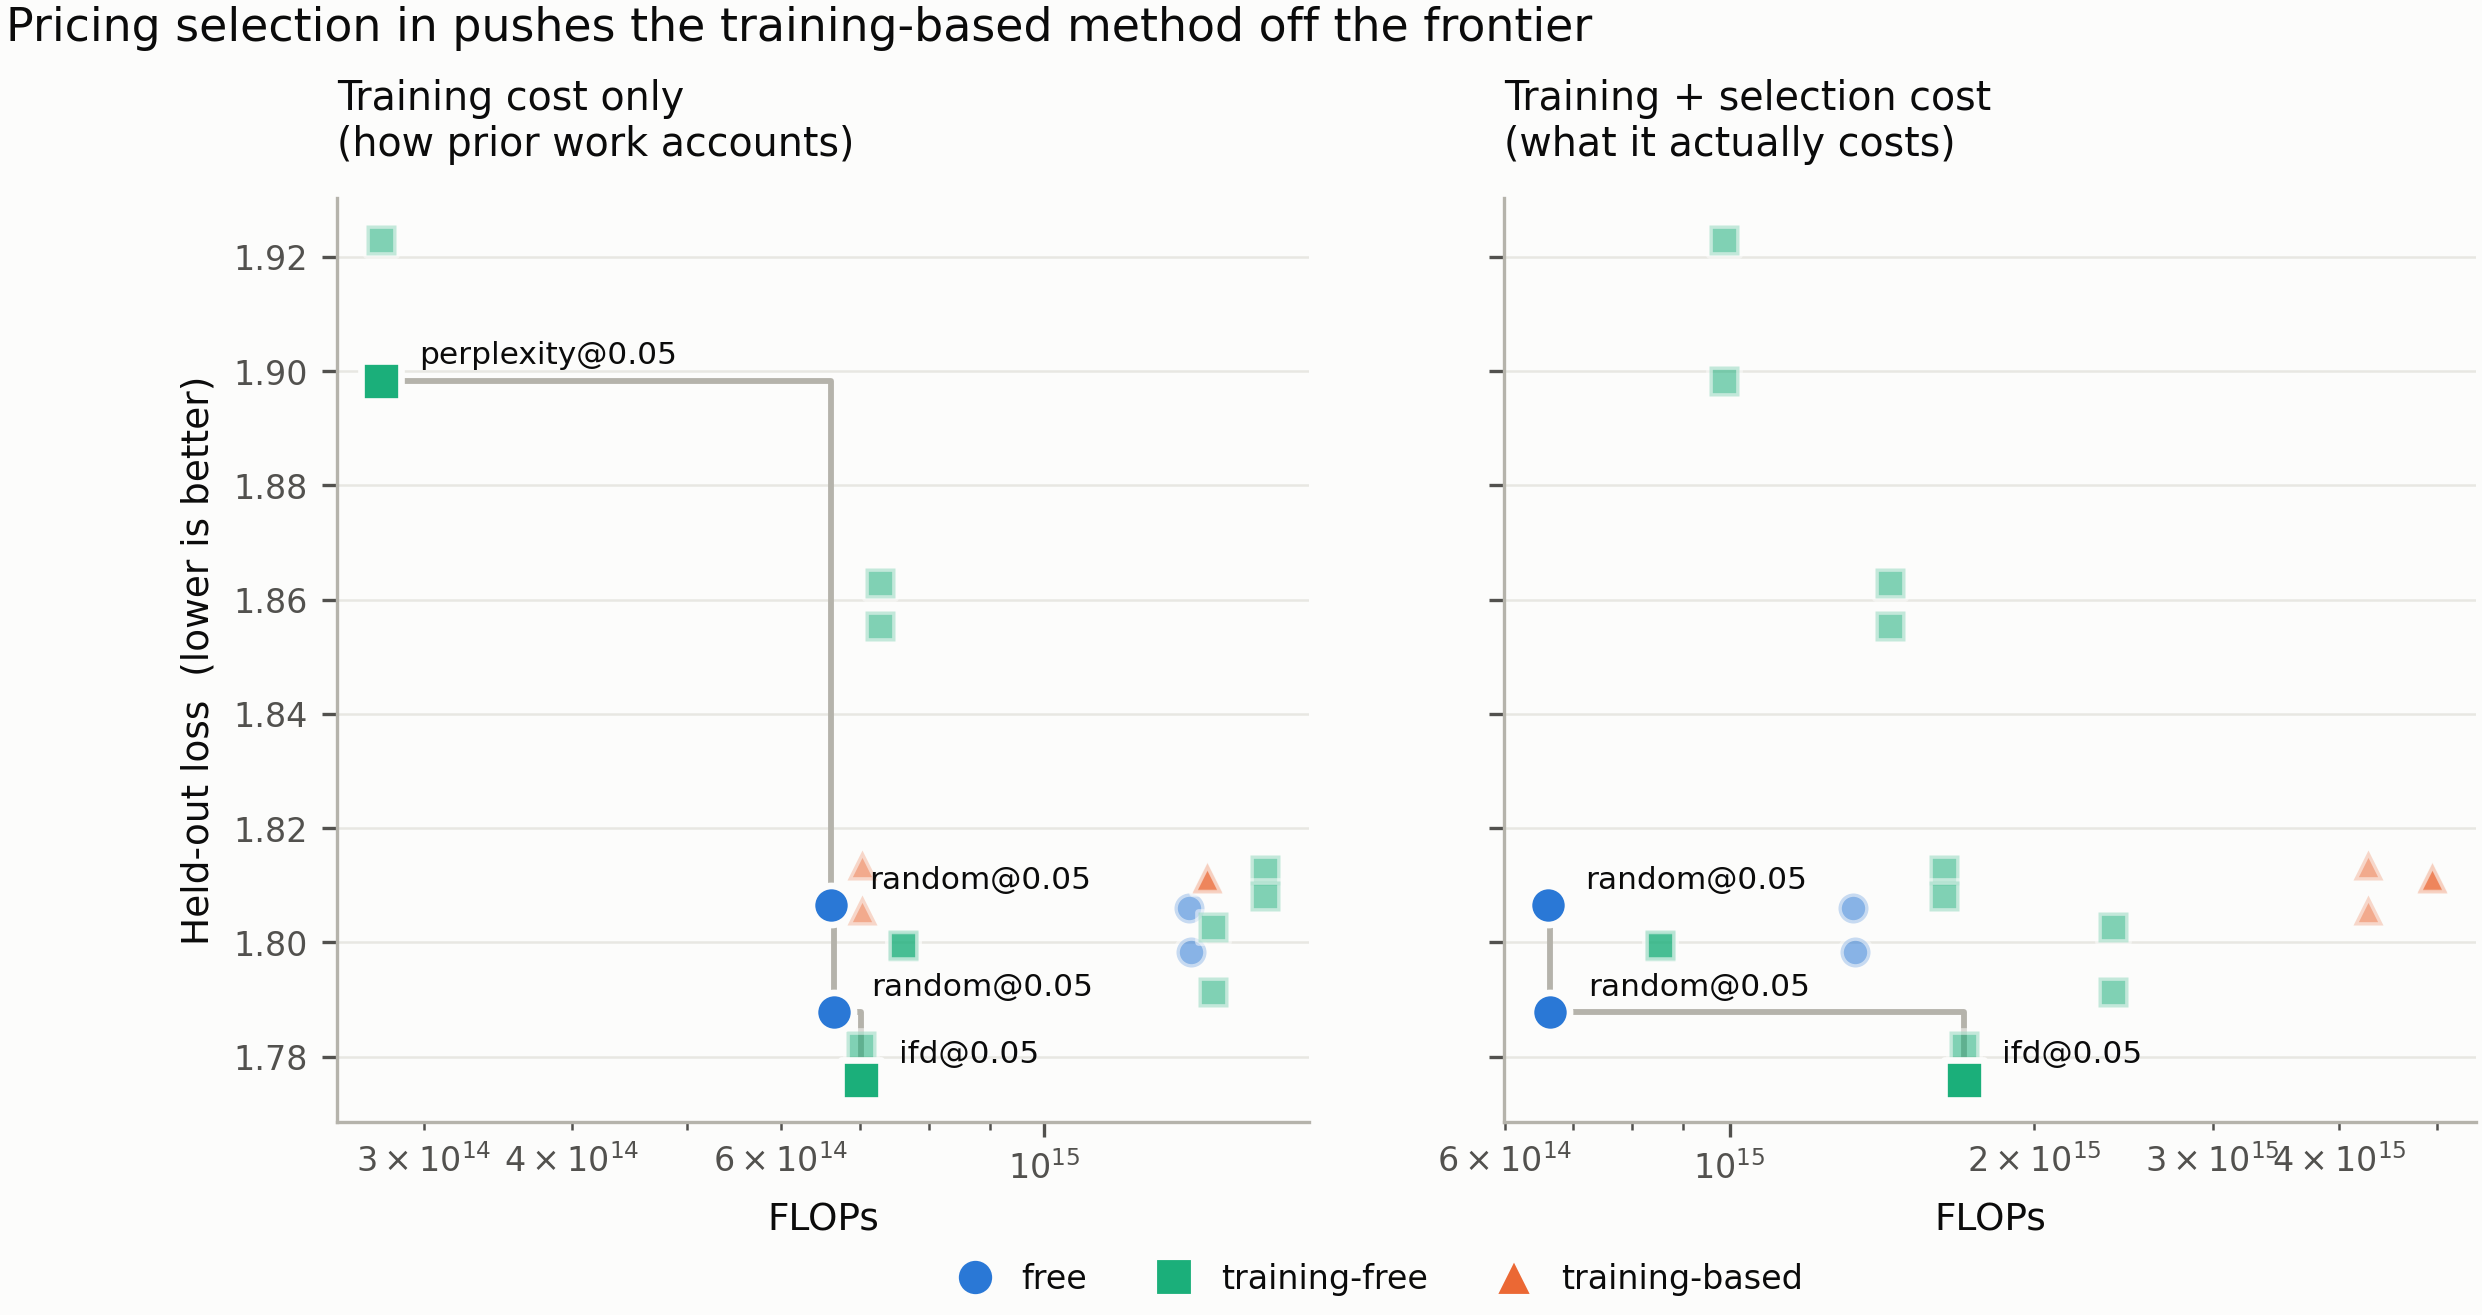

In [5]:
# Aggregate Main Grid Runs
grid_runs = [r for r in ok if r.get("study") in ("fast_grid", "study1_main_grid")]
agg = defaultdict(lambda: {"loss": [], "total_flops": [], "sel_share": []})

for r in grid_runs:
    c = r["config"]
    m = r["metrics"]
    key = (c["selection_method"], c["ratio"])
    agg[key]["loss"].append(m["held_out_loss"])
    agg[key]["total_flops"].append(r["cost"]["total_flops"])
    agg[key]["sel_share"].append(r["cost"]["selection_share_of_total_flops"])

res_table = []
for (method, ratio), data in sorted(agg.items(), key=lambda x: (x[0][1], np.mean(x[1]["loss"]))):
    res_table.append({
        "Method": method,
        "Ratio": f"{ratio*100:.0f}%",
        "Held-out Loss (Mean)": np.mean(data["loss"]),
        "Std Dev": np.std(data["loss"], ddof=1) if len(data["loss"]) > 1 else 0.0,
        "Selection FLOP Share (%)": np.mean(data["sel_share"]) * 100,
        "Total FLOPs": np.mean(data["total_flops"])
    })

df_grid = pd.DataFrame(res_table)
display(df_grid.style.format({
    "Held-out Loss (Mean)": "{:.4f}",
    "Std Dev": "{:.4f}",
    "Selection FLOP Share (%)": "{:.1f}%",
    "Total FLOPs": "{:.2e}"
}).set_caption("Main Grid Experimental Performance & Cost Share"))

p_pareto = ROOT / "results/figures/fig1_pareto.png"
if p_pareto.exists():
    print("\nFigure 4: Pareto Frontier comparison (Training Cost Only vs. Total Cost)")
    display(Image(filename=str(p_pareto)))

--- 
## 5. Hyperparameter Fragility & Ranking Stability Across Learning Rates (RQ1)

**Core Question (RQ1):** Do selection-method rankings hold when the target model's learning rate is re-tuned?

Prior research fixed learning rates across all methods. Below, we test method rankings across different learning rates ($1\times 10^{-6}$, $2\times 10^{-4}$, $5\times 10^{-4}$) to measure rank stability via Spearman rank correlation.

Figure 5: Ranking Stability Across Learning Rates


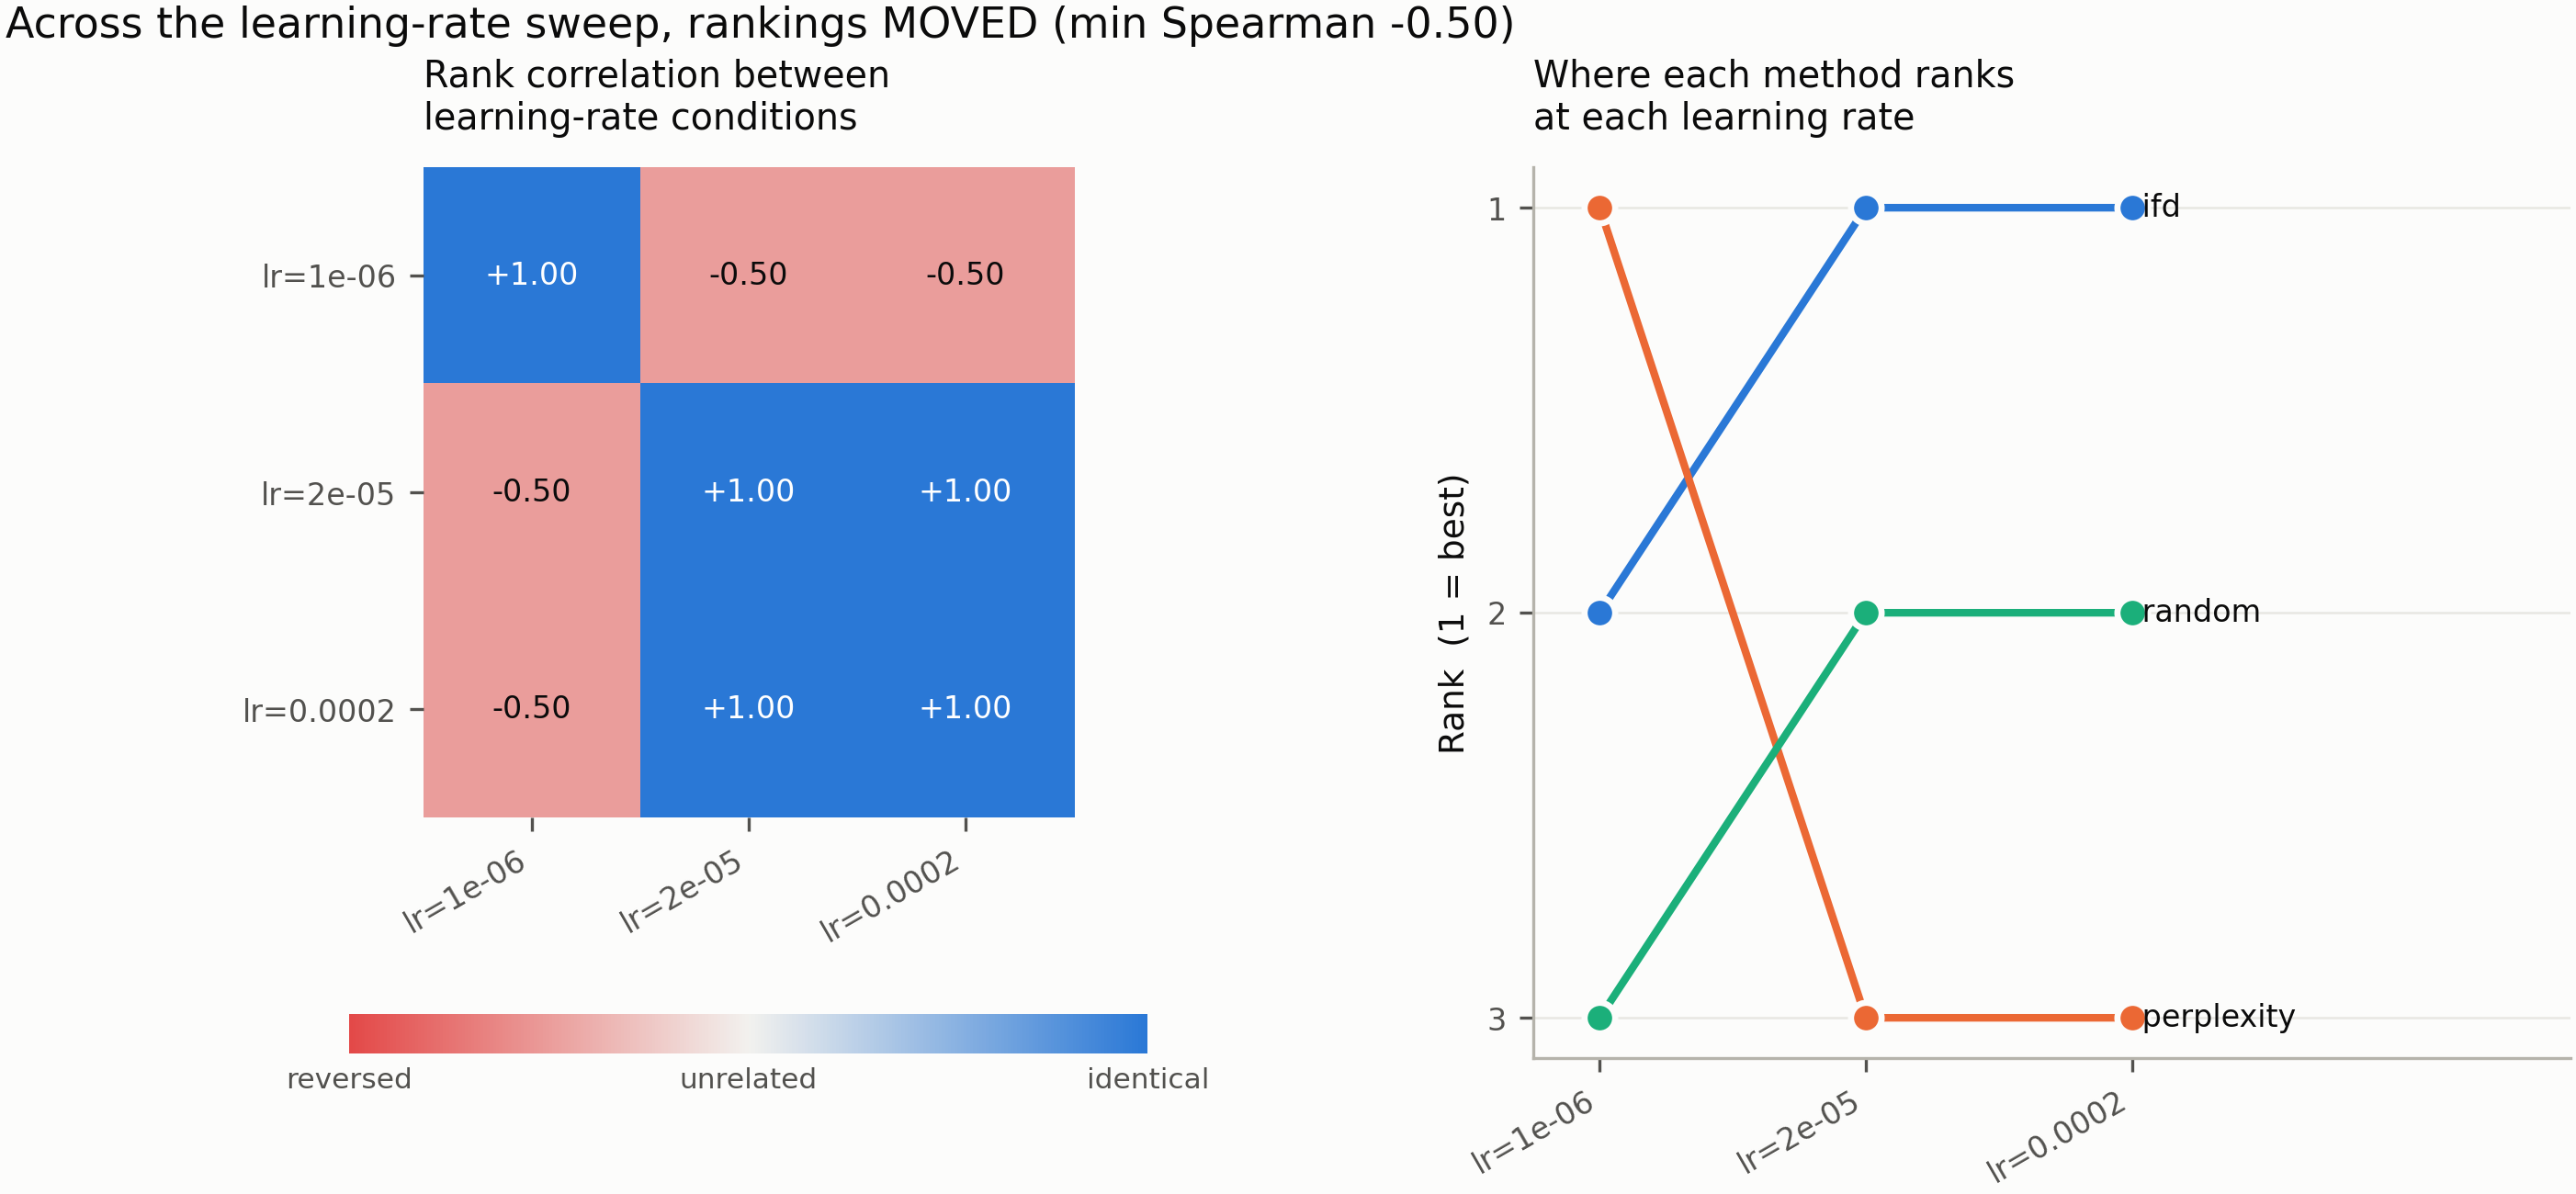

In [6]:
p_rank = ROOT / "results/figures/fig2_ranking_stability.png"
if p_rank.exists():
    print("Figure 5: Ranking Stability Across Learning Rates")
    display(Image(filename=str(p_rank)))
else:
    print("fig2_ranking_stability.png not found. Run scripts/figures.py to generate.")

--- 
## 6. Seed Variance & Statistical Significance Analysis

We inspect variance across random seeds to ensure performance differences are statistically significant and not noise.

Figure 6: Held-out Loss Variance Across Random Seeds


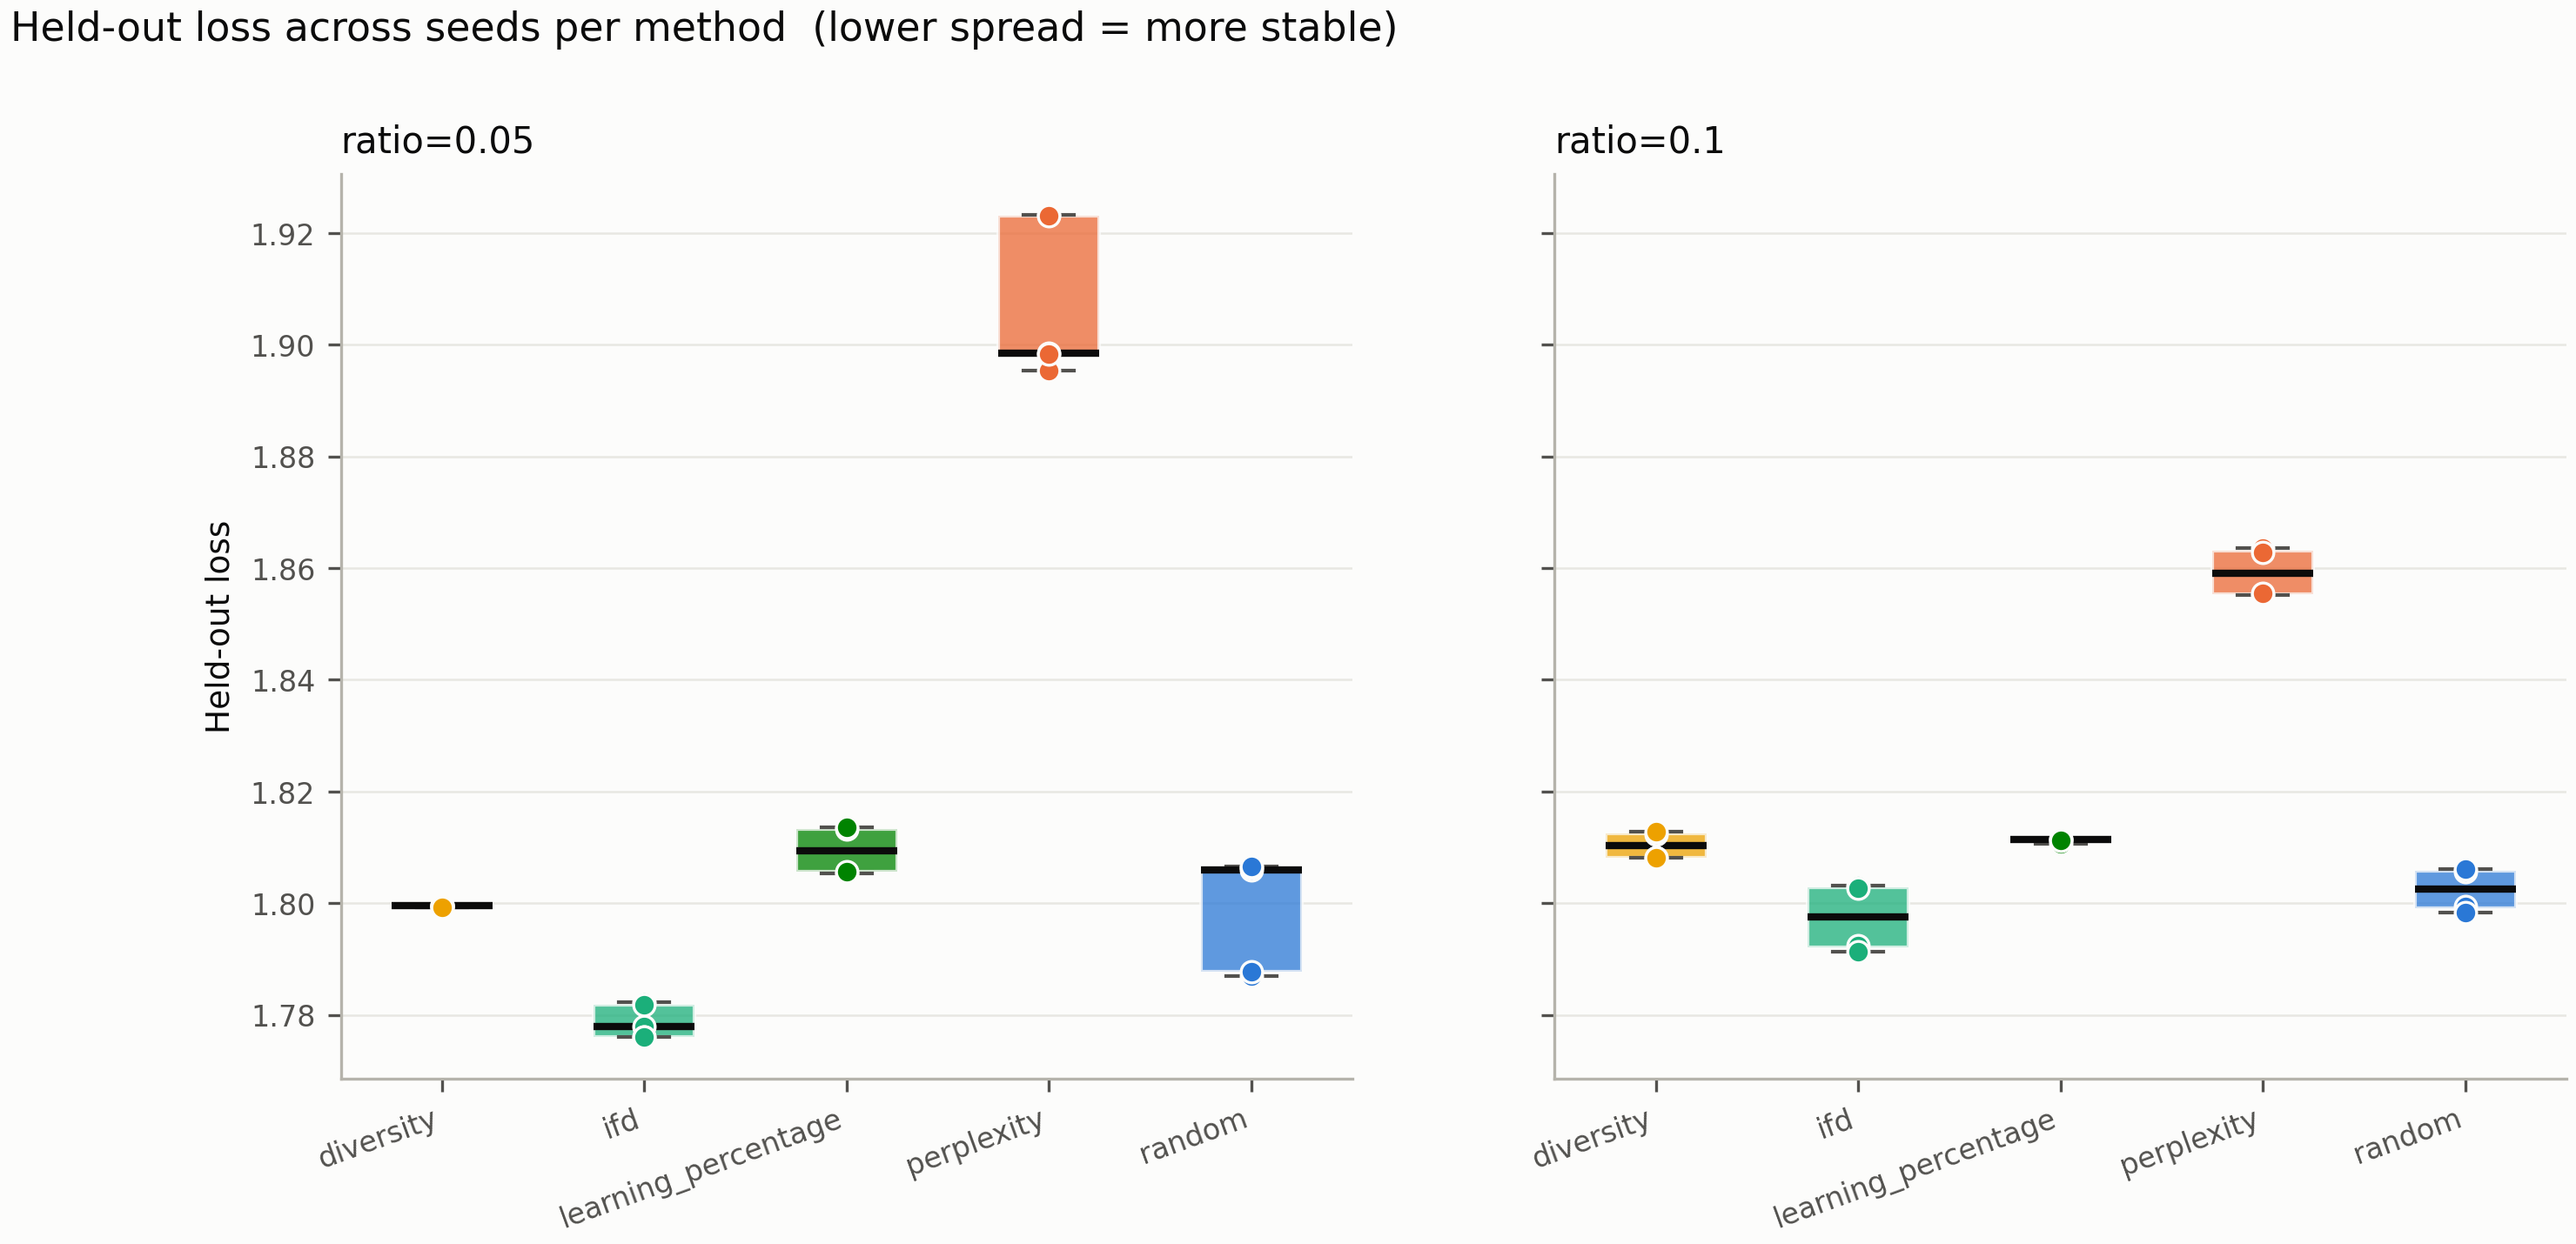

In [7]:
p_seed = ROOT / "results/figures/eda6_seed_variance.png"
if p_seed.exists():
    print("Figure 6: Held-out Loss Variance Across Random Seeds")
    display(Image(filename=str(p_seed)))

--- 
## 7. Summary of Empirical Findings & Paper Conclusions

1. **Selection FLOPs are Load-Bearing (RQ2)**:
   - Model-based selection algorithms spend **58.9% to 83.6%** of their total compute budget on selection alone.
   - When total compute is accounted for, training-based methods (`learning_percentage`) and raw `perplexity` fail to remain on the Pareto frontier.
   - `IFD` remains effective because its conditional/unconditional ratio delivers high quality per FLOP.

2. **Hyperparameter Fragility (RQ1)**:
   - Selection rankings do not stay fixed when the learning rate changes. Fixed hyperparameter evaluations create an illusion of method superiority.

3. **Practical Guidance for Practitioners**:
   - If your compute budget is tight, **Random selection** or lightweight **IFD** are the most cost-effective choices.
   - Never deploy computationally expensive selection methods without calculating whether selection cost exceeds training savings.